# H2. Связь времени доставки с оценкой заказа

## 1. Постановка задачи

### Бизнес-вопрос

Связано ли увеличение времени доставки со снижением оценки заказа покупателем?

### Нулевая гипотеза H0

Отрицательная монотонная связь между временем доставки и оценкой заказа отсутствует

### Альтернативная гипотеза H1

Увеличение времени доставки связано со снижением оценки заказа:

### Метод

Для проверки гипотезы используется коэффициент ранговой корреляции Спирмена, поскольку:

- время доставки является количественным признаком;
- оценка заказа принимает упорядоченные значения от 1 до 5;
- метод не требует нормального распределения признаков;
- исследуется монотонная связь между переменными.

Уровень значимости:
alpha = 0.05

## 2. Подготовка окружения

In [70]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sqlalchemy.engine import URL
from sqlalchemy import create_engine

In [71]:
import os
from dotenv import load_dotenv
_ = load_dotenv()

In [72]:
DB_USERNAME = os.getenv("DB_USERNAME")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USERNAME,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)

In [73]:
engine = create_engine(url=url)

## 3. Получение данных

Для анализа используются только доставленные заказы, для которых известны дата покупки, дата фактической доставки и оценка покупателя.

Для каждого заказа рассчитывается время доставки в днях

In [74]:
read_sql_query = """
SELECT
    o.order_id,
    EXTRACT(
        EPOCH FROM (
            o.order_delivered_customer_date
            - o.order_purchase_timestamp
        )
    ) / 86400.0 AS delivery_days,
    r.review_score
FROM orders AS o
JOIN order_reviews AS r
    ON o.order_id = r.order_id
WHERE
    o.order_status = 'delivered'
    AND o.order_purchase_timestamp IS NOT NULL
    AND o.order_delivered_customer_date IS NOT NULL
    AND r.review_score IS NOT NULL;
"""

df = pd.read_sql(sql=read_sql_query, con=engine)

## 4. Проверка качества данных

Перед проведением статистического анализа проверим:

- отсутствие пропущенных значений;
- допустимый диапазон оценок от 1 до 5;
- отсутствие отрицательного времени доставки;
- уникальность заказов после объединения таблиц.

In [75]:
df.head()

,order_id,delivery_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,4
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,4
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,5
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,5


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96353 entries, 0 to 96352
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       96353 non-null  str    
 1   delivery_days  96353 non-null  float64
 2   review_score   96353 non-null  int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 2.2 MB


In [77]:
sorted(df["review_score"].unique())

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

In [90]:
df[df["order_id"].duplicated()]

,order_id,delivery_days,review_score
388,ac7a92560a9e99f0a0ab4988102f491b,18.323889,1
533,7845a2492ab1b4f2cf3d56c7b8da1446,5.386146,5
644,acbe07f22f29ad7e5a78f30008cc6ec7,11.142812,5
787,c761a8b74f1e876bc5efc4186f720e27,7.804039,4
1058,5e4c365dd3cf7769a88981f408d069d3,31.779456,1
...,...,...,...
95777,66f943fd426ac8716ef6b6b97ace8bd8,15.475729,4
95948,76de574e14e58baded25a12dce8075c1,4.234398,5
95973,2fcdb0c004a2a538d3dd724ea76916bd,22.530845,5
96007,dbfa3d8c05cc5d84083fc259a9feb5bc,17.930127,5


In [78]:
quality_checks = pd.Series({
    "rows": len(df),
    "unique_orders": df["order_id"].nunique(),
    "duplicate_orders": df["order_id"].duplicated().sum(),
    "missing_values": df.isna().sum().sum(),
    "negative_delivery_days": (df["delivery_days"] < 0).sum(),
    "invalid_review_scores": (~df["review_score"].between(1, 5)).sum(),
})

quality_checks

rows                      96353
unique_orders             95824
duplicate_orders            529
missing_values                0
negative_delivery_days        0
invalid_review_scores         0
dtype: int64

## 5. Описательный анализ

Рассмотрим распределение оценок покупателей и сравним время доставки между группами с различными оценками.

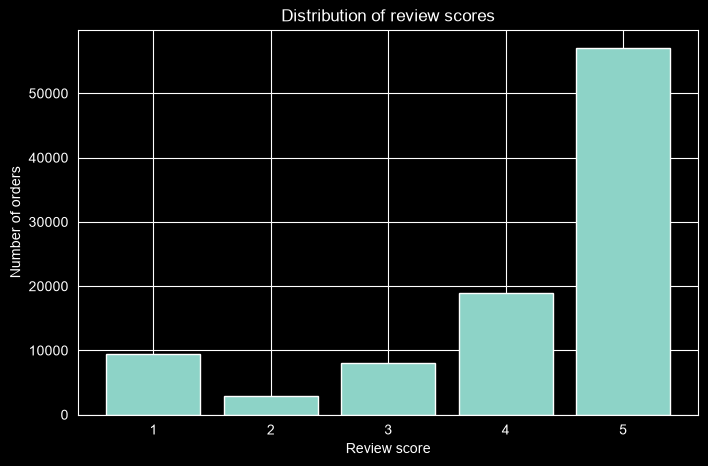

In [79]:
review_distribution = df["review_score"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(x=review_distribution.index, height=review_distribution.values)

plt.title("Distribution of review scores")
plt.xlabel("Review score")
plt.ylabel("Number of orders")

plt.show()

### 5.1. Время доставки в зависимости от оценки

Сравним распределения времени доставки для заказов с оценками от 1 до 5. Boxplot позволяет оценить медиану, разброс и наличие экстремально долгих доставок.

In [80]:
delivery_days_distribution = df[['delivery_days', 'review_score']].copy()

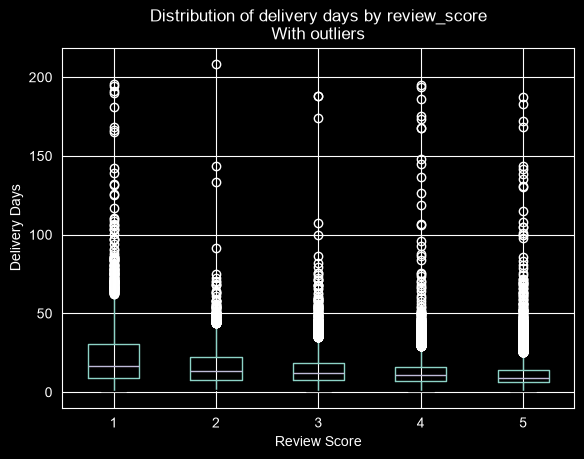

In [81]:
delivery_days_distribution.boxplot(column='delivery_days', by='review_score')

plt.title('With outliers')
plt.suptitle('Distribution of delivery days by review_score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Days')

plt.show()

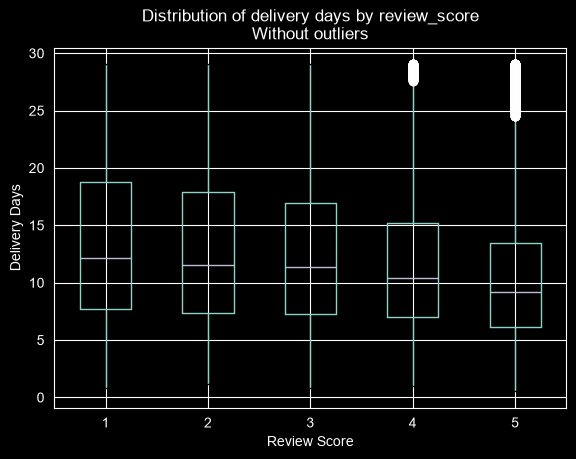

In [82]:
q1 = delivery_days_distribution['delivery_days'].quantile(0.25)
q3 = delivery_days_distribution['delivery_days'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

filtered_delivery_days_distribution = delivery_days_distribution[(delivery_days_distribution['delivery_days'] >= lower_bound) & (delivery_days_distribution['delivery_days'] <= upper_bound)]

filtered_delivery_days_distribution.boxplot(column='delivery_days', by='review_score')

plt.title('Without outliers')
plt.suptitle('Distribution of delivery days by review_score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Days')

plt.show()

### 5.2. Описательная статистика по оценкам

Рассчитаем среднее и медианное время доставки для каждой оценки заказа.

In [83]:
review_stats = (
    df.groupby("review_score")["delivery_days"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
)

review_stats

,count,mean,median,std,q25,q75
review_score,,,,,,
1,9405,21.311499,16.784190,16.057158,9.224861,30.500961
2,2941,16.660580,13.249688,12.486433,8.011597,22.313183
3,7961,14.259974,12.049097,9.928728,7.635324,18.477743
4,18987,12.312356,10.792986,8.282839,7.052882,15.940388
5,57059,10.688660,9.235197,6.819695,6.158137,13.855295


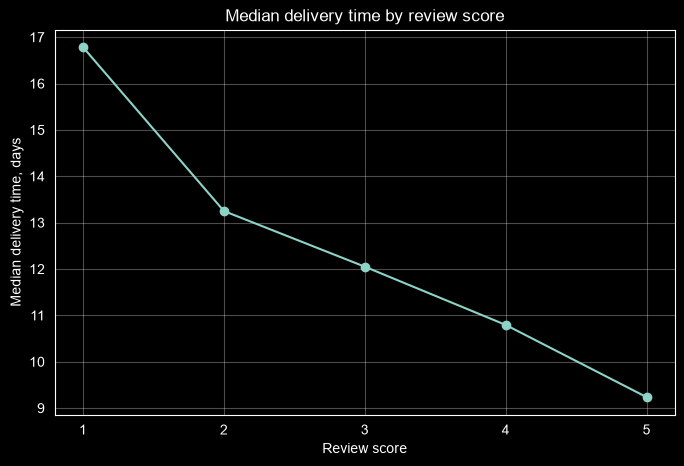

In [84]:
median_delivery = (
    df.groupby("review_score")["delivery_days"]
    .median()
)

plt.figure(figsize=(8, 5))

plt.plot(
    median_delivery.index,
    median_delivery.values,
    marker="o"
)

plt.title("Median delivery time by review score")
plt.xlabel("Review score")
plt.ylabel("Median delivery time, days")
plt.xticks(range(1, 6))
plt.grid(alpha=0.3)

plt.show()

## 6. Проверка статистической гипотезы

Для оценки монотонной связи между временем доставки и оценкой заказа используется коэффициент корреляции Спирмена.

Критерий принятия решения:

- если (p < 0.05), нулевая гипотеза отвергается;
- если (p >=  0.05), оснований для отклонения нулевой гипотезы недостаточно.

In [85]:
ALPHA = 0.05

spearman_result = stats.spearmanr(
    df["delivery_days"],
    df["review_score"],
    alternative="less"
)

rho = spearman_result.statistic
p_value = spearman_result.pvalue

print(f"Spearman rho: {rho:.4f}")
print(f"p-value: {p_value:.3e}")

if p_value < ALPHA:
    print("Reject H0")
    print("There is evidence of a negative monotonic relationship.")
else:
    print("Fail to reject H0")
    print("There is insufficient evidence of a negative monotonic relationship.")

Spearman rho: -0.2344
p-value: 0.000e+00
Reject H0
There is evidence of a negative monotonic relationship.


## 7. Оценка неопределённости

Помимо точечной оценки коэффициента корреляции рассчитаем 95% доверительный интервал с помощью bootstrap.

In [86]:
def bootstrap_spearman_ci(
    x,
    y,
    n_iterations=2000,
    confidence_level=0.95,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    x = np.asarray(x)
    y = np.asarray(y)

    n = len(x)
    correlations = []

    for _ in range(n_iterations):
        indices = rng.integers(0, n, size=n)

        correlation = stats.spearmanr(
            x[indices],
            y[indices]
        ).statistic

        correlations.append(correlation)

    alpha = 1 - confidence_level

    lower = np.quantile(
        correlations,
        alpha / 2
    )

    upper = np.quantile(
        correlations,
        1 - alpha / 2
    )

    return lower, upper

In [87]:
ci_lower, ci_upper = bootstrap_spearman_ci(
    df["delivery_days"],
    df["review_score"]
)

print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI: [-0.2403, -0.2282]


In [88]:
results = pd.DataFrame({
    "metric": [
        "Spearman rho",
        "p-value",
        "CI lower",
        "CI upper",
        "alpha"
    ],
    "value": [
        rho,
        p_value,
        ci_lower,
        ci_upper,
        ALPHA
    ]
})

results

,metric,value
0,Spearman rho,-0.234364
1,p-value,0.000000
2,CI lower,-0.240278
3,CI upper,-0.228216
4,alpha,0.050000


## 8. Результаты и вывод

Получены следующие результаты:

- коэффициент Спирмена: (rho_s = -0.234);
- статистическая связь является значимой: (p < 0.05);
- 95% доверительный интервал для коэффициента корреляции:
  [-0.240; -0.228].

Нулевая гипотеза отвергается.

Между временем доставки и оценкой заказа наблюдается статистически значимая отрицательная монотонная связь: более длительные доставки в среднем связаны с более низкими оценками покупателей.

При этом абсолютное значение коэффициента корреляции составляет около 0.23, поэтому сила связи относительно невелика. Время доставки является одним из факторов, связанных с оценкой заказа, но не объясняет её полностью.

### Бизнес-интерпретация

Заказы с низкими оценками характеризуются существенно большим медианным временем доставки. Медиана составляет около 16.8 дня для оценки 1 против 9.2 дня для оценки 5.

Следовательно, сокращение времени доставки потенциально может быть связано с улучшением клиентского опыта. Однако данный анализ показывает статистическую связь, а не причинно-следственный эффект.